In [1]:
import pandas as pd
import numpy as np

In [5]:
df = pd.read_csv('../datasets/salary.csv')
df

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


In [9]:
x = df[['YearsExperience']]
y = df['Salary']

In [10]:
# Step2 split data into training and testing set 
# pip install scikit-learn
from sklearn.model_selection import train_test_split

x_train, x_test , y_train, y_test = train_test_split(x,y,test_size=0.20,random_state=101)

In [11]:
# step 3 fit simple linear regression to training data 
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[9440.46]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['YearsExperience']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.604e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [20]:
x_test

,YearsExperience
20,6.8
24,8.7
7,3.2
18,5.9
2,1.5
27,9.6


In [26]:
# step 4: make prediction

y_pred = model.predict(x_test)
print('predicted values on test set: ',y_pred )

predicted values on test set:  [ 90235.22172621 108172.10301013  56249.55192509  81738.80427593
  40200.76340789 116668.52046041]


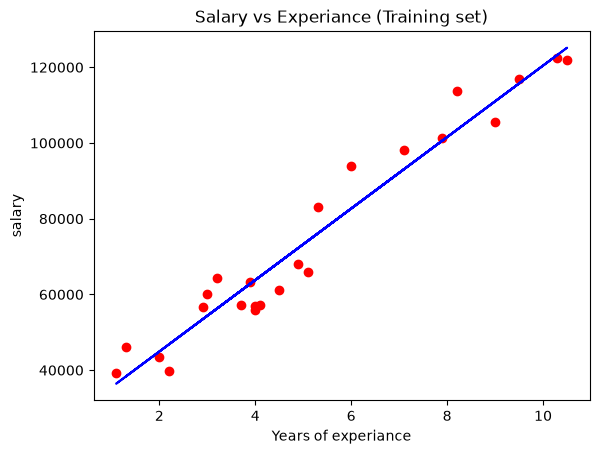

In [21]:
# step 5: visualize training set results
import matplotlib.pyplot as plt
plt.scatter(x_train, y_train, color='red')
plt.plot(x_train, model.predict(x_train), color='blue')
plt.title('Salary vs Experiance (Training set)')
plt.xlabel('Years of experiance')
plt.ylabel('salary')
plt.show()


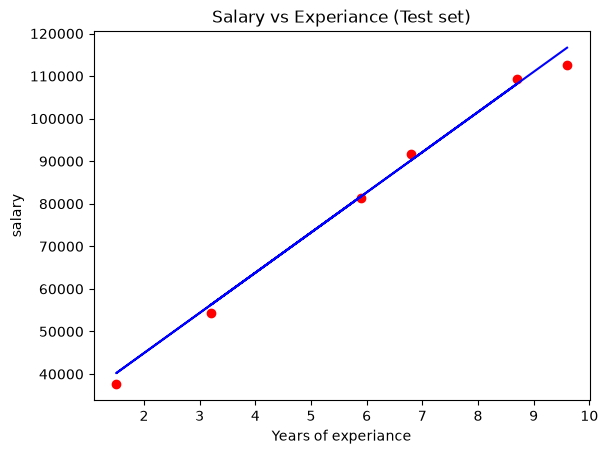

In [23]:
# step 6: visualize test set results

plt.scatter(x_test, y_test, color='red')
plt.plot(x_test, model.predict(x_test), color='blue')
plt.title('Salary vs Experiance (Test set)')
plt.xlabel('Years of experiance')
plt.ylabel('salary')
plt.show()

In [31]:
# step 7 make new prediction
new_x_vals = pd.DataFrame({'YearsExperience':[1,3,5,8,5,15,20,25]})
new_y_pred = model.predict(new_x_vals)
print('prediction for new expericance vals: ',new_y_pred)

prediction for new expericance vals:  [ 35480.53149107  54361.45915836  73242.38682565 101563.77832658
  73242.38682565 167647.0251621  214849.34433032 262051.66349855]


In [30]:
# step 8 model evaluation
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f''' 
Model evaluation metrics:

Mean absolute error (MAE) : {mae:.4f}
Mean Squared Error (MSE): {mse:.4f}
R2 Score (r2): {r2:.4f}

''')

 
Model evaluation metrics:

Mean absolute error (MAE) : 1907.5526
Mean Squared Error (MSE): 4934969.8785
R2 Score (r2): 0.9934




# Exercide 1: predict house sale price using gr living area housing.csv

In [37]:
df= pd.read_csv('../datasets/housing.csv')
df

,Id,LotArea,OverallQual,YearBuilt,TotalBsmtSF,GrLivArea,FullBath,BedroomAbvGr,KitchenQual,TotRmsAbvGrd,GarageArea,SalePrice
0,1,8450,7,2003,856,1710,2,3,Gd,8,548,208500
1,2,9600,6,1976,1262,1262,2,3,TA,6,460,181500
2,3,11250,7,2001,920,1786,2,3,Gd,6,608,223500
3,4,9550,7,1915,756,1717,1,3,Gd,7,642,140000
4,5,14260,8,2000,1145,2198,2,4,Gd,9,836,250000
...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,7917,6,1999,953,1647,2,3,TA,7,460,175000
1456,1457,13175,6,1978,1542,2073,2,3,TA,7,500,210000
1457,1458,9042,7,1941,1152,2340,2,4,Gd,9,252,266500
1458,1459,9717,5,1950,1078,1078,1,2,Gd,5,240,142125


In [39]:
x=df[['GrLivArea']]
y=df['SalePrice']

x_train, x_test , y_train, y_test = train_test_split(x,y,test_size=0.80,random_state=101)

model = LinearRegression()
model.fit(x_train, y_train)

model.predict(x_test)

array([228621.62765299, 178017.39258354, 129399.68740319, ...,
       134836.50604702, 151356.07038787, 212833.94274496], shape=(1168,))

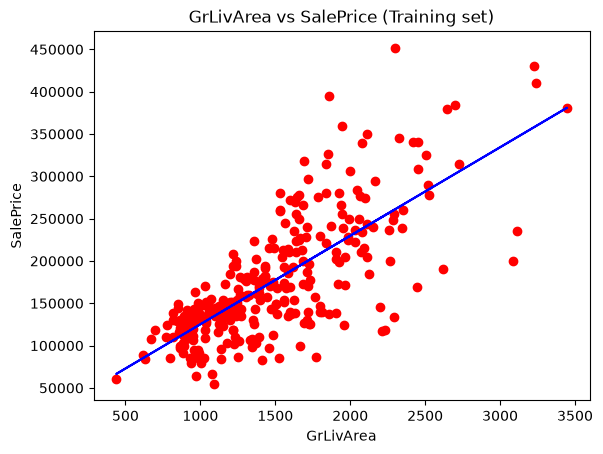

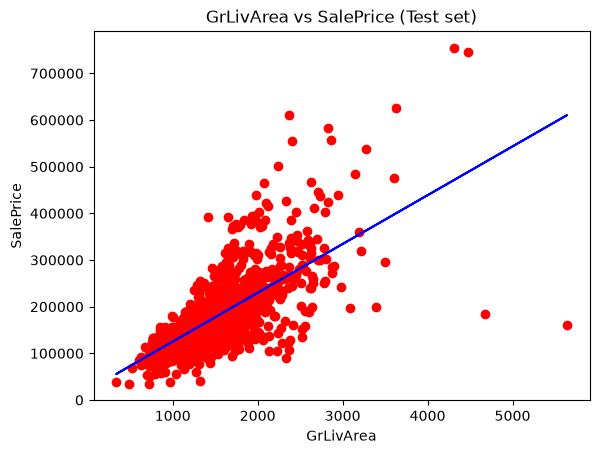

In [43]:
#   visualize training set results
import matplotlib.pyplot as plt
plt.scatter(x_train, y_train, color='red')
plt.plot(x_train, model.predict(x_train), color='blue')
plt.title('GrLivArea vs SalePrice (Training set)')
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.show()

#  visualize test set results

plt.scatter(x_test, y_test, color='red')
plt.plot(x_test, model.predict(x_test), color='blue')
plt.title('GrLivArea vs SalePrice (Test set)')
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.show()


Multiple Linear Regression

In [57]:
x=df[['GrLivArea','OverallQual','LotArea']]          # x-> more than one feature multiple linear regression
y=df['SalePrice']

x_train, x_test , y_train, y_test = train_test_split(x,y,test_size=0.80,random_state=101)

model = LinearRegression()
model.fit(x_train, y_train)

y_res = model.predict(x_test)

In [63]:
y_res

array([265931.06205715, 141530.13378227, 117925.57411289, ...,
        77648.73586355, 185208.96644482, 178580.00215329], shape=(1168,))

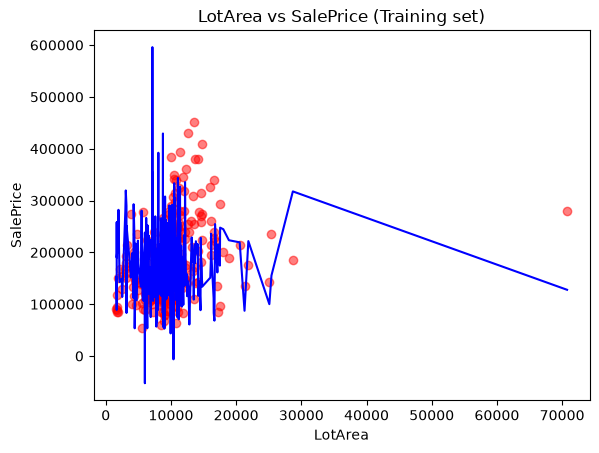

In [66]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Sort x_train values so the regression line plots smoothly
sort_idx = np.argsort(x_train['LotArea'])
x_sorted = x_train['LotArea'].iloc[sort_idx]
y_res_sorted = y_res[sort_idx] if isinstance(y_res, np.ndarray) else y_res.iloc[sort_idx]

# 2. Plot scatter and line
plt.scatter(x_train['LotArea'], y_train, color='red', alpha=0.5)
plt.plot(x_sorted, y_res_sorted, color='blue')

# 3. Add Labels & Corrected Title
plt.title('LotArea vs SalePrice (Training set)')
plt.xlabel('LotArea')
plt.ylabel('SalePrice')
plt.show()